In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import pandas_udf, PandasUDFType
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, ArrayType, MapType
import pandas as pd


In [3]:
import sys
import os
import time
# Add the src/ directory to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src/")))

In [4]:
# Check if there's an active Spark context and stop it
from pyspark import SparkContext
if SparkContext._active_spark_context:
    print("Stopping existing Spark context...")
    SparkContext._active_spark_context.stop()
    print("Previous Spark context stopped successfully")

In [5]:
# Set environment variables
os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'

# Create new session with explicit local binding
spark = SparkSession.builder \
    .appName("EEG_Analysis") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.driver.host", "127.0.0.1") \
    .master("local[*]") \
    .getOrCreate()

print("New Spark session created successfully")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/06 12:42:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


New Spark session created successfully


25/04/06 12:42:26 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/04/06 12:42:26 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/04/06 12:42:26 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


In [6]:
spark = SparkSession.builder.appName("MyApp").getOrCreate()


25/04/06 12:42:26 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [7]:
from populate_schemas import load_subjects_df, extract_features_udtf
from feature_extraction import processEpoch, processSub
from schema_definition import get_feature_schema, get_subject_schema


# from feature_extraction

In [8]:
# preprocess_sets.setProjectRootDir()
subject_df = load_subjects_df(spark)


In [9]:
ROOT_DIR = ".."
SRC_DIR = ROOT_DIR + "/src"

In [10]:
sc = spark.sparkContext
# Add all necessary modules
try:
    sc.addPyFile(os.path.join(SRC_DIR, "feature_extraction.py"))
    print("Added feature_extraction.py to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "preprocess_sets.py"))
    print("Added preprocess_sets to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "schema_definition.py"))
    print("Added schema_definition.py to the pyspark context")
except Exception as e:
    print(f"Error adding files to SparkContext: {e}")

Added feature_extraction.py to the pyspark context
Added preprocess_sets to the pyspark context
Added schema_definition.py to the pyspark context


In [11]:
%%time
result = (
    subject_df
    .filter((subject_df.SubjectID == "sub-001"))
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)
result.show()

/Users/admin/neuro-venv/lib/python3.9/site-packages/pyspark/sql/pandas/group_ops.py:104: UserWarning: It is preferred to use 'applyInPandas' over this API. This API will be deprecated in the future releases. See SPARK-28264 for more details.
  warnings.warn(
function ran                                                        (0 + 1) / 1]
Processing subject sub-001
processSub sub-001
subPath sub-001
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set
Got 398 epochs for sub-001
<class 'mne.epochs.Epochs'>
Epoch 0
<class 'mne.epochs.Epochs'>
<class 'mne.epochs.Epochs'>
Epoch 1
<class 'mne.epochs.Epochs'>
<class 'mne.epochs.Epochs'>
Total rows collected: 37810
Returning DataFrame with 37810 rows
Column names from schema: ['SubjectID', 'EpochID', 'WaveBand', 'Electrode', 'Power']
4.321402072906494
                                                                                

+---------+-------+--------+---------+--------------------+
|SubjectID|EpochID|WaveBand|Electrode|               Power|
+---------+-------+--------+---------+--------------------+
|  sub-001|   ep-0|   Delta|      Fp1| 0.08257892642542033|
|  sub-001|   ep-0|   Theta|      Fp1|0.005611645685714301|
|  sub-001|   ep-0|   Alpha|      Fp1|0.001143220388171...|
|  sub-001|   ep-0|    Beta|      Fp1|1.958040080323613...|
|  sub-001|   ep-0|   Total|      Fp1|0.011235955056179773|
|  sub-001|   ep-0|   Delta|      Fp2| 0.08389220643958975|
|  sub-001|   ep-0|   Theta|      Fp2|0.004672355992737972|
|  sub-001|   ep-0|   Alpha|      Fp2|9.638188967593915E-4|
|  sub-001|   ep-0|    Beta|      Fp2|1.768820461211869...|
|  sub-001|   ep-0|   Total|      Fp2|0.011235955056179771|
|  sub-001|   ep-0|   Delta|       F3| 0.08212274846138015|
|  sub-001|   ep-0|   Theta|       F3|0.005595318986261473|
|  sub-001|   ep-0|   Alpha|       F3|0.001112336388491...|
|  sub-001|   ep-0|    Beta|       F3|2.

In [12]:
%%time
# Start both groups processing (lazy evaluation means these won't execute yet)
result_group_a = (
    subject_df
    .filter(subject_df.Group == "A")
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)

result_group_c = (
    subject_df
    .filter(subject_df.Group == "C")
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)

# Force execution of both by calling an action on each
# This launches both jobs in parallel
from pyspark.sql import functions as F

# Use persist to cache the results in memory
result_group_a = result_group_a.persist()
result_group_c = result_group_c.persist()

# Trigger execution with actions
count_a = result_group_a.count()
count_c = result_group_c.count()

print(f"Processed {count_a} records for Alzheimer's group")
print(f"Processed {count_c} records for Control group")

function ran==========================================>        (168 + 10) / 200]
Processing subject sub-020
processSub sub-020
function ran
Processing subject sub-029
processSub sub-029
function ran
Processing subject sub-011
processSub sub-011
function ran
Processing subject sub-016
processSub sub-016
function ran
Processing subject sub-018
processSub sub-018
function ran
Processing subject sub-001
processSub sub-001
function ran
Processing subject sub-002
processSub sub-002
function ran
Processing subject sub-021
processSub sub-021
function ran
Processing subject sub-017
processSub sub-017
function ran
Processing subject sub-012
processSub sub-012
subPath sub-020
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-020/eeg/sub-020_task-eyesclosed_eeg.set
subPath sub-029
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-029/eeg/sub-029_task-eyesclosed_eeg.set
subPath sub-016
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-016/eeg/sub-016_task-eyesclosed_eeg.set
subPath sub-018
Pa

Processed 1856870 records for Alzheimer's group
Processed 1543465 records for Control group
CPU times: user 322 ms, sys: 252 ms, total: 574 ms
Wall time: 4min 27s


In [17]:
result_group_a.show

<bound method DataFrame.show of DataFrame[SubjectID: string, EpochID: string, WaveBand: string, Electrode: string, Power: float, label: int]>

In [18]:
result_group_a.show(2)

+---------+-------+--------+---------+------------+-----+
|SubjectID|EpochID|WaveBand|Electrode|       Power|label|
+---------+-------+--------+---------+------------+-----+
|  sub-020|   ep-0|   Delta|      Fp1|  0.07823379|    1|
|  sub-020|   ep-0|   Theta|      Fp1|0.0065223426|    1|
+---------+-------+--------+---------+------------+-----+
only showing top 2 rows



In [19]:
from pyspark.sql.functions import col, mean as _mean, stddev as _stddev, broadcast, lit
from pyspark.sql.types import FloatType

# Step 1: Convert Power to float32
result_group_a = result_group_a.withColumn("Power", col("Power").cast(FloatType()))
result_group_c = result_group_c.withColumn("Power", col("Power").cast(FloatType()))
result_group_a = result_group_a.withColumn("label", lit(1))
result_group_c = result_group_c.withColumn("label", lit(0))

In [20]:
# Step 2: Compute mean and std from result_group_a only * added union
full_df = result_group_a.union(result_group_c)
norm_stats = full_df.groupBy("Electrode", "WaveBand").agg(
    _mean("Power").alias("mean_power"),
    _stddev("Power").alias("std_power")
)

In [21]:
norm_stats.head(3)

[Row(Electrode='T5', WaveBand='Alpha', mean_power=0.005252557521045713, std_power=0.006567790853310042),
 Row(Electrode='Pz', WaveBand='Alpha', mean_power=0.0031537372083167274, std_power=0.0038182864201296986),
 Row(Electrode='F4', WaveBand='Delta', mean_power=0.07971921558250293, std_power=0.007917400290853086)]

In [22]:
# Step 3: Broadcast join stats to both result_group_a and result_group_c
full_df = full_df.join(
    broadcast(norm_stats), on=["Electrode", "WaveBand"]
)


In [23]:
full_df.head(3)

[Row(Electrode='Fp1', WaveBand='Delta', SubjectID='sub-020', EpochID='ep-0', Power=0.07823379337787628, label=1, mean_power=0.07929838219624444, std_power=0.008222817358672627),
 Row(Electrode='Fp1', WaveBand='Theta', SubjectID='sub-020', EpochID='ep-0', Power=0.006522342562675476, label=1, mean_power=0.005327228971971614, std_power=0.003931092935816067),
 Row(Electrode='Fp1', WaveBand='Alpha', SubjectID='sub-020', EpochID='ep-0', Power=0.00359321478754282, label=1, mean_power=0.002659409741484907, std_power=0.0030160173288932383)]

In [24]:
from pyspark.sql.functions import when

full_df_norm = full_df.withColumn(
    "Power",
    (col("Power") - col("mean_power")) /
    when((col("std_power").isNotNull()) & (col("std_power") != 0), col("std_power")).otherwise(1.0) #this otherwise sets std to 1 and since std is 0 mean_power - power = 0
)



In [25]:
# Step 5 (optional): Drop extra columns
full_df_norm = full_df_norm.drop("mean_power", "std_power")

In [26]:
full_df_norm.show(10)

+---------+--------+---------+-------+--------------------+-----+
|Electrode|WaveBand|SubjectID|EpochID|               Power|label|
+---------+--------+---------+-------+--------------------+-----+
|      Fp1|   Delta|  sub-020|   ep-0|-0.12946764739281624|    1|
|      Fp1|   Theta|  sub-020|   ep-0|  0.3040156033491905|    1|
|      Fp1|   Alpha|  sub-020|   ep-0| 0.30961527876916517|    1|
|      Fp1|    Beta|  sub-020|   ep-0|-0.44430232368623573|    1|
|      Fp1|   Total|  sub-020|   ep-0|                 0.0|    1|
|      Fp2|   Delta|  sub-020|   ep-0|-0.18955361367211143|    1|
|      Fp2|   Theta|  sub-020|   ep-0|  0.4048158529054603|    1|
|      Fp2|   Alpha|  sub-020|   ep-0| 0.14924802208200036|    1|
|      Fp2|    Beta|  sub-020|   ep-0|-0.23126612915226288|    1|
|      Fp2|   Total|  sub-020|   ep-0|                 0.0|    1|
+---------+--------+---------+-------+--------------------+-----+
only showing top 10 rows



In [94]:
from pyspark.sql.functions import concat_ws

full_df_norm = full_df_norm.withColumn(
    "Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand")
)

In [95]:
full_df_norm.filter((col("Electrode") == "F3") & (col("WaveBand") == "Total")).show()


+---------+--------+---------+-------+-----+-----+------------------+
|Electrode|WaveBand|SubjectID|EpochID|Power|label|Electrode_WaveBand|
+---------+--------+---------+-------+-----+-----+------------------+
|       F3|   Total|  sub-020|   ep-0|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-020|   ep-1|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-020|   ep-2|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-020|   ep-3|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-020|   ep-4|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-020|   ep-5|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-020|   ep-6|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-020|   ep-7|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-020|   ep-8|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-020|   ep-9|  0.0|    1|          F3_Total|
|       F3|   Total|  sub-020|  ep-10|  0.0|    1|          F3_Total|
|       F3|   Total|

In [96]:
pivot_keys = [row["Electrode_WaveBand"] for row in full_df_norm.select("Electrode_WaveBand").distinct().collect()]

In [230]:
pivot_keys[:4]

['T4_Beta', 'Fp2_Beta', 'P3_Alpha', 'O2_Alpha']

In [247]:
# features_df = (
#     full_df_norm
#     .groupBy("SubjectID")
#     .pivot("Electrode_WaveBand", pivot_keys)
#     .agg({"Power": "first"})  # Or "avg", depending on your use case
# )

features_df = (
    full_df_norm
    .groupBy("EpochID", "SubjectID", 'label')
    .pivot("Electrode_WaveBand", pivot_keys)
    .agg({"Power": "first"})  # Or "avg", depending on your use case
)
# features_df = features_df.drop("EpochID")


In [248]:
features_df.count()

35793

In [249]:
features_df.columns

['EpochID',
 'SubjectID',
 'label',
 'T4_Beta',
 'Fp2_Beta',
 'P3_Alpha',
 'O2_Alpha',
 'T3_Delta',
 'F7_Delta',
 'F8_Beta',
 'T4_Alpha',
 'F3_Delta',
 'P4_Theta',
 'T3_Beta',
 'F7_Theta',
 'T5_Theta',
 'P4_Alpha',
 'T6_Alpha',
 'Cz_Alpha',
 'T5_Alpha',
 'Cz_Delta',
 'F4_Alpha',
 'Pz_Beta',
 'Fp1_Total',
 'F4_Theta',
 'O2_Beta',
 'O1_Beta',
 'Pz_Total',
 'Pz_Alpha',
 'Fp2_Alpha',
 'O1_Delta',
 'C3_Theta',
 'Cz_Theta',
 'T5_Total',
 'C4_Alpha',
 'Cz_Total',
 'T4_Total',
 'P3_Total',
 'Fp1_Delta',
 'Fz_Delta',
 'Cz_Beta',
 'Fz_Total',
 'T6_Total',
 'F8_Alpha',
 'C4_Delta',
 'F4_Total',
 'O1_Alpha',
 'F3_Beta',
 'F4_Delta',
 'Fp2_Total',
 'P3_Beta',
 'C4_Theta',
 'Pz_Delta',
 'P3_Delta',
 'Fp1_Beta',
 'Fp1_Alpha',
 'P4_Delta',
 'F7_Total',
 'T5_Beta',
 'O2_Total',
 'F7_Alpha',
 'T6_Delta',
 'F4_Beta',
 'F8_Delta',
 'F8_Total',
 'O2_Theta',
 'P4_Total',
 'Fz_Beta',
 'C4_Beta',
 'T3_Total',
 'F8_Theta',
 'C3_Total',
 'F3_Theta',
 'O2_Delta',
 'T4_Delta',
 'Fp1_Theta',
 'Fp2_Theta',
 'C3_Del

In [250]:
features_df.head(1)

[Row(EpochID='ep-105', SubjectID='sub-037', label=0, T4_Beta=-0.471622042756016, Fp2_Beta=-0.5415155427049688, P3_Alpha=1.549205316203724, O2_Alpha=0.21548800708676577, T3_Delta=0.2416510529142272, F7_Delta=0.1289577644786794, F8_Beta=-0.592969090482622, T4_Alpha=-0.3211039226998951, F3_Delta=0.3190584602405037, P4_Theta=-0.22659980842070743, T3_Beta=-0.5482585990040086, F7_Theta=0.22979163687295223, T5_Theta=0.14875410902049627, P4_Alpha=-0.3425318417736818, T6_Alpha=-0.2884042174262419, Cz_Alpha=-0.22476597835205933, T5_Alpha=0.6388295419673524, Cz_Delta=0.46313864834988716, F4_Alpha=-0.07254549353434256, Pz_Beta=-0.5626836731428677, Fp1_Total=0.0, F4_Theta=-0.41986976079559923, O2_Beta=-0.570216550031867, O1_Beta=-0.5916376716838921, Pz_Total=0.0, Pz_Alpha=1.026467317334851, Fp2_Alpha=0.0823007770452868, O1_Delta=-0.5347668774690758, C3_Theta=-0.32838189619128133, Cz_Theta=-0.5151931326911716, T5_Total=0.0, C4_Alpha=-0.42638515098140556, Cz_Total=0.0, T4_Total=0.0, P3_Total=0.0, Fp1

In [251]:
len(features_df.head(1)[0])

98

In [252]:
from pyspark.ml.feature import VectorAssembler

# remove 'SubjectID' from the feature list
feature_cols = [col for col in features_df.columns if col not in ("SubjectID", "label", "EpochID")]
# feature_cols = [col for col in features_df.columns if (col != "SubjectID")]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
# assembled_df = assembler.transform(features_df).select("SubjectID", "EpochID", "features")
assembled_df = assembler.transform(features_df).select("features")

In [253]:
feature_cols[:4]
"label" in feature_cols

False

In [254]:
assembled_df.columns

['features']

In [255]:
assembled_df.head(2)

[Row(features=DenseVector([-0.4716, -0.5415, 1.5492, 0.2155, 0.2417, 0.129, -0.593, -0.3211, 0.3191, -0.2266, -0.5483, 0.2298, 0.1488, -0.3425, -0.2884, -0.2248, 0.6388, 0.4631, -0.0725, -0.5627, 0.0, -0.4199, -0.5702, -0.5916, 0.0, 1.0265, 0.0823, -0.5348, -0.3284, -0.5152, 0.0, -0.4264, 0.0, 0.0, 0.0, 0.1424, 0.4194, -0.3318, 0.0, 0.0, -0.0511, 0.5429, 0.0, 0.6195, -0.3607, 0.4494, 0.0, -0.6545, -0.414, -0.2963, -0.5073, -0.396, -0.047, 0.4582, 0.0, -0.6552, 0.0, -0.3427, 0.1434, -0.5484, 0.446, 0.0, 0.7344, 0.0, -0.3254, -0.5439, 0.0, -0.3878, 0.0, -0.0484, -0.3032, 0.449, 0.0245, -0.3005, 0.264, -0.4815, -0.2316, -0.2752, -0.6155, 0.0, 0.6183, -0.3767, 0.2583, 0.0, 0.0451, -0.116, 0.0, -0.2848, 0.3783, 0.3157, -0.107, -0.5276, -0.3243, -0.2769, -0.4628])),
 Row(features=DenseVector([0.3974, 0.0668, -0.544, -0.5715, -0.3009, -0.2301, -0.1393, -0.3001, -0.3276, 1.2572, 0.0111, 0.8116, 1.7174, -0.4959, -0.5188, -0.3179, -0.5975, -0.3589, -0.2319, 0.3432, 0.0, 0.8868, 0.773, 0.7619, 0.

In [256]:
len(assembled_df.head(1)[0][0])

95

In [257]:
from pyspark.ml.feature import PCA

pca = PCA(k=20, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(assembled_df)
pca_result = pca_model.transform(assembled_df)

In [258]:
explained_variance = pca_model.explainedVariance.toArray()

In [259]:
explained_variance

array([0.10402498, 0.099452  , 0.08713386, 0.0758483 , 0.070604  ,
       0.06464098, 0.06048944, 0.05466837, 0.04870932, 0.04298461,
       0.03717626, 0.03571966, 0.02945699, 0.02875681, 0.02532797,
       0.02338432, 0.02019476, 0.01948661, 0.01539516, 0.01464114])

In [260]:
sum(explained_variance[:8])

np.float64(0.6168619179157689)

In [261]:
sum(explained_variance[:11])

np.float64(0.745732107827915)

In [262]:
sum(explained_variance[:18])

np.float64(0.928059226239442)

In [263]:
assembled_df.printSchema()

root
 |-- features: vector (nullable = true)



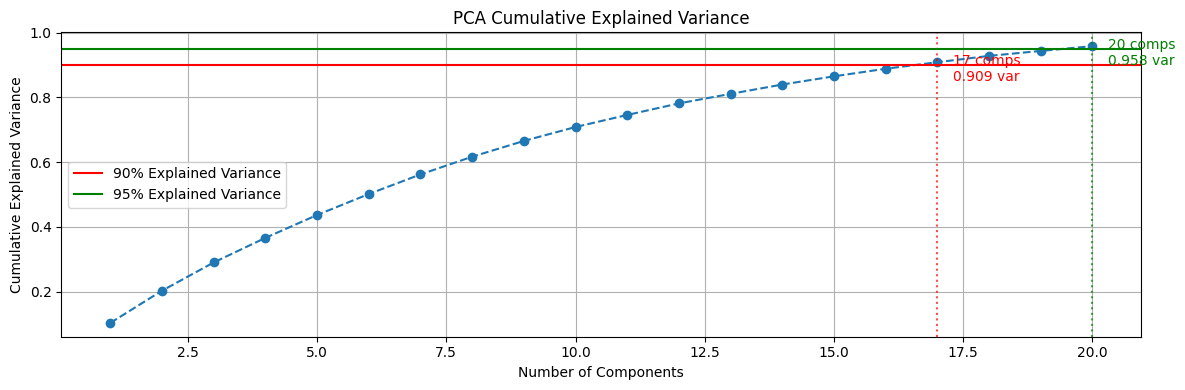

In [213]:
import matplotlib.pyplot as plt
import numpy as np

# Get the variance values from PySpark
explained_variance = pca_model.explainedVariance.toArray()
cumulative_variance = np.cumsum(explained_variance)

# Find component index where thresholds are reached
thresholds = [0.90, 0.95]
threshold_indices = [np.argmax(cumulative_variance >= t) for t in thresholds]

# Plot
plt.figure(figsize=(12, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')

# Draw horizontal and vertical lines at thresholds
colors = ['r', 'g']
for idx, t in zip(threshold_indices, thresholds):
    comp_number = idx + 1
    cum_var = cumulative_variance[idx]

    # Horizontal line
    plt.axhline(y=t, color=colors[thresholds.index(t)], linestyle='-', label=f'{int(t*100)}% Explained Variance')
    # Vertical line
    plt.axvline(x=comp_number, color=colors[thresholds.index(t)], linestyle=':', alpha=0.7)
    # Annotation
    plt.text(comp_number + 0.3, t - 0.05, f'{comp_number} comps\n{cum_var:.3f} var', color=colors[thresholds.index(t)])

# Labels & Legend
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Doing pyspark ML

In [194]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

# Turn vector into individual PC columns
pca_result = pca_result.withColumn("pca_array", vector_to_array("pca_features"))

# Select label + principal components
for i in range(k_val):
    pca_result = pca_result.withColumn(f"PC{i+1}", col("pca_array")[i])

# Final dataframe with PCs
full_df = pca_result.select("SubjectID", "EpochID", *[f"PC{i+1}" for i in range(k_val)])


AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `EpochID` cannot be resolved. Did you mean one of the following? [`PC1`, `PC10`, `PC11`, `PC12`, `PC13`].;
'Project ['EpochID, PC1#386535, PC2#386557, PC3#386579, PC4#386601, PC5#386623, PC6#386645, PC7#386667, PC8#386689, PC9#386711, PC10#386733, PC11#386755, PC12#386777, PC13#386799, PC14#386821, PC15#386843, PC16#386865, PC17#386887, PC18#386909]
+- Project [features#277519, pca_features#385842, pca_array#386513, PC1#386535, PC2#386557, PC3#386579, PC4#386601, PC5#386623, PC6#386645, PC7#386667, PC8#386689, PC9#386711, PC10#386733, PC11#386755, PC12#386777, PC13#386799, PC14#386821, PC15#386843, PC16#386865, PC17#386887, pca_array#386513[17] AS PC18#386909]
   +- Project [features#277519, pca_features#385842, pca_array#386513, PC1#386535, PC2#386557, PC3#386579, PC4#386601, PC5#386623, PC6#386645, PC7#386667, PC8#386689, PC9#386711, PC10#386733, PC11#386755, PC12#386777, PC13#386799, PC14

In [180]:
assembled_df.head()

Row(features=DenseVector([-0.2415, -0.6862, -0.6798, -0.6738, 0.6394, 0.8045, -0.4655, -0.8, 0.6338, -0.7961, -0.3195, -0.7066, -0.8673, -0.7618, -0.7489, -0.6618, -0.5914, 0.6785, -0.6795, -0.5285, 0.0, -0.711, -0.6355, -0.517, 0.0, -0.6948, -0.65, 0.9613, -0.5431, -0.6129, 0.0, -0.669, 0.0, 0.0, 0.0, 0.7121, 0.7662, -0.4473, 0.0, 0.0, -0.6457, 0.7662, 0.0, -0.6585, -0.4339, 0.8431, 0.0, -0.4717, -0.7217, 0.883, 0.8716, -0.3769, -0.6052, 0.9235, 0.0, -0.3335, 0.0, -0.622, 0.9731, -0.6083, 0.7046, 0.0, -0.9337, 0.0, -0.5576, -0.4878, 0.0, -0.54, 0.0, -0.5039, 0.9984, 0.7206, -0.6524, -0.6657, 0.6112, -0.5928, -0.7955, -0.4873, -0.5475, 0.0, -0.9283, -0.6401, -0.5799, 0.0, -0.5814, -0.7721, 0.0, -0.6558, -0.8502, 0.8498, -0.5586, -0.5053, 0.8456, -0.6095, -0.4057]))

In [183]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=pca_cols, outputCol="features")
train_df = assembler.transform(train_df).select("features", "label")
test_df = assembler.transform(test_df).select("features", "label")

from pyspark.sql.types import IntegerType
train_df = train_df.withColumn("label", train_df["label"].cast(IntegerType()))
test_df = test_df.withColumn("label", test_df["label"].cast(IntegerType()))

NameError: name 'pca_cols' is not defined

Using top 18 components to explain 0.95% variance


# WHY TF IS IT GETTING DIFFERNET EXPLAINED VARIENCES

# Using the functions created to normalize

In [15]:
from dimensionality_reduction import normalize_power

In [16]:
df_a_norm, df_c_norm = normalize_power(result_group_a, result_group_c)

In [18]:
df_a_norm.show(30)

+---------+--------+---------+-------+--------------------+
|Electrode|WaveBand|SubjectID|EpochID|               Power|
+---------+--------+---------+-------+--------------------+
|      Fp1|   Delta|  sub-020|   ep-0|-0.22287221524788234|
|      Fp1|   Theta|  sub-020|   ep-0| 0.23452256993451262|
|      Fp1|   Alpha|  sub-020|   ep-0|   0.652996502786586|
|      Fp1|    Beta|  sub-020|   ep-0| -0.3898200899055782|
|      Fp1|   Total|  sub-020|   ep-0|                 0.0|
|      Fp2|   Delta|  sub-020|   ep-0|-0.27248447938609727|
|      Fp2|   Theta|  sub-020|   ep-0|  0.3297128332901876|
|      Fp2|   Alpha|  sub-020|   ep-0| 0.45484677266657936|
|      Fp2|    Beta|  sub-020|   ep-0|-0.19059251944965738|
|      Fp2|   Total|  sub-020|   ep-0|                 0.0|
|       F3|   Delta|  sub-020|   ep-0| 0.06729569195896423|
|       F3|   Theta|  sub-020|   ep-0|-0.13344110219088656|
|       F3|   Alpha|  sub-020|   ep-0| 0.14764310589818766|
|       F3|    Beta|  sub-020|   ep-0|-0

In [79]:
import pickle

# Convert to Pandas first
df_a_pd = df_a_norm.toPandas()

df_a_pd.to_pickle("eeg_features_alz_pygrnd6.pkl")
# Save to a pickle file


In [19]:
# put the label for the dataframes
from pyspark.sql.functions import lit
df_a = df_a_norm.withColumn("label", lit(1))
df_c = df_c_norm.withColumn("label", lit(0))
full_df = df_a.union(df_c)

In [20]:
# splitting training and testing


group_a_subjects = (
    full_df.filter(full_df["label"] == 0)
    .select("SubjectID")
    .distinct()
    .orderBy("SubjectID")
    .rdd.map(lambda r: r[0])
    .collect()
)

group_c_subjects = (
    full_df.filter(full_df["label"] == 1)
    .select("SubjectID")
    .distinct()
    .orderBy("SubjectID")
    .rdd.map(lambda r: r[0])
    .collect()
)


test_subjects = group_a_subjects[-3:] + group_c_subjects[-3:]

# Filter the full_df to split into train and test based on SubjectID
train_df = full_df.filter(~full_df.SubjectID.isin(test_subjects))
test_df = full_df.filter(full_df.SubjectID.isin(test_subjects))

In [21]:
import dimensionality_reduction

In [22]:
from dimensionality_reduction import prepare_features_for_pca, fit_pca_model, apply_pca_model

In [23]:
#  prepare features for PCA

from dimensionality_reduction import prepare_features_for_pca
train_feat_df, feature_cols = prepare_features_for_pca(train_df)
test_feat_df, _ = prepare_features_for_pca(test_df)

In [26]:
pca_model, k = fit_pca_model(train_feat_df, feature_cols, variance_target=0.95)

# TODO: getting different number of PCA values then playground 4 and 5  so ? Maybe check difference between dataframes if they are different  

In [54]:
k

20

In [55]:
pca_model.explainedVariance.toArray()

array([0.10395404, 0.09881219, 0.09020643, 0.07630289, 0.07345073,
       0.06325665, 0.05846561, 0.05142891, 0.0469734 , 0.0441241 ,
       0.03620411, 0.0345958 , 0.03207046, 0.0291238 , 0.02520649,
       0.02271144, 0.02102785, 0.01968885, 0.01458948, 0.01431236])

In [56]:
sum( pca_model.explainedVariance.toArray())

np.float64(0.9565055762312851)

In [57]:
from pyspark.ml.feature import VectorAssembler

feature_cols = [c for c in train_feat_df.columns if c not in ("SubjectID", "EpochID", "label")]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_train_df = assembler.transform(train_feat_df)

from pyspark.ml.feature import PCA

pca = PCA(k=20, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(assembled_train_df)
pca_result = pca_model.transform(assembled_train_df)

In [58]:
# Apply the PCA to both sets
train_pca = apply_pca_model(train_feat_df, feature_cols, pca_model, k)
test_pca = apply_pca_model(test_feat_df, feature_cols, pca_model, k)

In [59]:
train_pca.show(4) # why are there 20 pc's when should be 17 or 18 ? 

[Stage 420:>                                                      (0 + 10) / 11]

+---------+-------+-----+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+--------------------+--------------------+-------------------+--------------------+
|SubjectID|EpochID|label|                PC1|                 PC2|                 PC3|                 PC4|                 PC5|                 PC6|                 PC7|                 PC8|                 PC9|                PC10|                PC11|                PC12|                PC13|                PC14|                PC15|              PC16|                PC17|                PC18|               PC19|                PC20|
+---------+-------+-----+-------------------+--------------------+--------------------+--------------------+--------

# this is the ML part to test  

In [70]:
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import col

# 1. Automatically get PCA feature columns (PC1, PC2, ..., PCk)
pca_cols = [c for c in train_pca.columns if c.startswith("PC")]

In [71]:
# 2. Assemble vector features
assembler = VectorAssembler(inputCols=pca_cols, outputCol="features")
train_df_vec = assembler.transform(train_pca).select("features", "label")
test_df_vec = assembler.transform(test_pca).select("features", "label")

In [72]:
# 3. Define the neural network (MLP)
input_dim = len(pca_cols)  # should match number of PCs used
mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=[input_dim, 100, 2],  # input → hidden (100) → output (2 classes)
    maxIter=1000,
    seed=42
)


In [73]:
# 4. Train and predict
mlp_model = mlp.fit(train_df_vec)
mlp_preds = mlp_model.transform(test_df_vec)

# 5. Evaluate results
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(mlp_preds)
print(f"Neural Net Accuracy: {accuracy:.4f}")


Neural Net Accuracy: 0.6196


In [78]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Convert Spark predictions to Pandas
preds_pd = mlp_preds.select("prediction", "label").toPandas()

# Accuracy
print("Neural Network Accuracy:", accuracy_score(preds_pd["label"], preds_pd["prediction"]))

# F1 Score (weighted)
print("Weighted F1 Score:", f1_score(preds_pd["label"], preds_pd["prediction"], average="weighted"))

# Full classification report
target_names = ["Control", "Alzheimer's"]
print(classification_report(preds_pd["label"], preds_pd["prediction"], target_names=target_names))


Neural Network Accuracy: 0.6196066921044907
Weighted F1 Score: 0.6176738501867369
              precision    recall  f1-score   support

     Control       0.64      0.55      0.59      1691
 Alzheimer's       0.61      0.69      0.65      1716

    accuracy                           0.62      3407
   macro avg       0.62      0.62      0.62      3407
weighted avg       0.62      0.62      0.62      3407



In [68]:
train_pca.columns

['SubjectID',
 'EpochID',
 'label',
 'PC1',
 'PC2',
 'PC3',
 'PC4',
 'PC5',
 'PC6',
 'PC7',
 'PC8',
 'PC9',
 'PC10',
 'PC11',
 'PC12',
 'PC13',
 'PC14',
 'PC15',
 'PC16',
 'PC17',
 'PC18',
 'PC19',
 'PC20']

In [69]:
from pyspark.ml.feature import VectorAssembler

pca_cols = [c for c in train_pca.columns if c.startswith("PC")]  # e.g., ["PC1", "PC2", ..., "PC11"]

assembler = VectorAssembler(inputCols=pca_cols, outputCol="features")
train_df_vec = assembler.transform(train_df)
test_df_vec = assembler.transform(test_df)

IllegalArgumentException: PC1 does not exist. Available: Electrode, WaveBand, SubjectID, EpochID, Power, label

In [66]:
print([c for c in train_df.columns if c.startswith("PC")])


[]


In [64]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import size

# Convert 'features' vector to an array, then compute size
train_df_vec.withColumn("feature_size", size(vector_to_array("features"))).select("feature_size").distinct().show()


[Stage 455:=======================================>            (300 + 10) / 400]

+------------+
|feature_size|
+------------+
|           0|
+------------+



In [61]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

# Get input size from PCA features
input_dim = len(feature_cols)

mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=[input_dim, 100, 2],  # input → hidden (100 units) → 2 output classes
    maxIter=1000,
    seed=42
)

mlp_model = mlp.fit(train_df_vec)
mlp_preds = mlp_model.transform(test_df_vec)

25/04/05 19:31:57 WARN BlockManager: Putting block rdd_653_12 failed due to exception java.lang.ArrayIndexOutOfBoundsException: arraycopy: last source index 95 out of bounds for double[0].
25/04/05 19:31:57 WARN BlockManager: Block rdd_653_12 could not be removed as it was not found on disk or in memory
25/04/05 19:31:57 WARN BlockManager: Putting block rdd_653_23 failed due to exception java.lang.ArrayIndexOutOfBoundsException: arraycopy: last source index 95 out of bounds for double[0].
25/04/05 19:31:57 WARN BlockManager: Block rdd_653_23 could not be removed as it was not found on disk or in memory
25/04/05 19:31:57 WARN BlockManager: Putting block rdd_653_22 failed due to exception java.lang.ArrayIndexOutOfBoundsException: arraycopy: last source index 95 out of bounds for double[0].
25/04/05 19:31:57 WARN BlockManager: Block rdd_653_22 could not be removed as it was not found on disk or in memory
25/04/05 19:31:57 ERROR Executor: Exception in task 22.0 in stage 444.0 (TID 12607)
j

Py4JJavaError: An error occurred while calling o1429.fit.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 34 in stage 444.0 failed 1 times, most recent failure: Lost task 34.0 in stage 444.0 (TID 12619) (localhost executor driver): java.lang.ArrayIndexOutOfBoundsException: arraycopy: last source index 95 out of bounds for double[0]
	at java.base/java.lang.System.arraycopy(Native Method)
	at org.apache.spark.ml.ann.DataStacker.$anonfun$stack$4(Layer.scala:665)
	at org.apache.spark.ml.ann.DataStacker.$anonfun$stack$4$adapted(Layer.scala:664)
	at scala.collection.immutable.List.foreach(List.scala:431)
	at org.apache.spark.ml.ann.DataStacker.$anonfun$stack$3(Layer.scala:664)
	at scala.collection.Iterator$$anon$10.next(Iterator.scala:461)
	at scala.collection.Iterator$$anon$10.next(Iterator.scala:461)
	at org.apache.spark.storage.memory.MemoryStore.putIterator(MemoryStore.scala:224)
	at org.apache.spark.storage.memory.MemoryStore.putIteratorAsValues(MemoryStore.sca